# CIFAR-10 -- Transfer Learning with VGG19

In this notebook, we explore transfer learning on CIFAR‑10 using VGG19 pretrained on ImageNet.  
The goal is to compare a large pretrained model with the custom CNN developed in the previous notebooks.

We follow a standard transfer learning pipeline:

1. Train a classifier head on top of a frozen VGG19 backbone  
2. Fine‑tune the last convolutional layers  
3. Add regularization (Dropout) to mitigate overfitting  
4. Evaluate the final model with a confusion matrix and misclassified examples

## 1 - Librairies

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import layers, mixed_precision
from sklearn.metrics import confusion_matrix
import itertools
import random
import os

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", mixed_precision.global_policy())

Mixed precision policy: <DTypePolicy "mixed_float16">


## 2 - Data Loading & Preprocessing

### 2.1 - Data Loading

In [2]:
(data_train, data_test, data_val), infos = tfds.load(
    'cifar10',
    split=[
        'train[:48000]',              # 80%
        'train[48000:]+test[:4000]',  # 10%
        'test[4000:]'                 # 10%
    ],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.HBRPOI_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.HBRPOI_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
Dataset loaded successfully.


### 2.2 - Preprocessing

In [3]:
# Preprocessing Layer -> Resize + Rescale
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(32, 32),
    tf.keras.layers.Rescaling(1.0 / 255)
])

# Preprocessing Functions
def preprocess(dataset):

    dataset = dataset.shuffle(buffer_size=1000,seed=SEED)

    # Resize + rescale
    dataset = dataset.map(
        lambda x, y: (resize_rescale(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch + prefetch
    dataset = dataset.batch(64)
    return dataset.prefetch(tf.data.AUTOTUNE)

# Create Preprocessed Datasets
batch_train = preprocess(data_train)
batch_val   = preprocess(data_val)
batch_test  = preprocess(data_test)

## 3 - Model Setup

### 3.1 Callbacks

In [4]:
def get_callbacks(name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"checkpoints/{name}.weights.h5",
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            mode="max"
        )
    ]

### 3.2 - Create Function

In [5]:
def create_vgg(
    input_shape=(32, 32, 3),
    add_dropout=False,
    dropout_rate=0.2,
    lr_head=1e-3,
    seed=SEED
) :

  tf.random.set_seed(seed)

  base_model = tf.keras.applications.VGG19(
      include_top=False,
      input_shape=input_shape,
      weights='imagenet'
      )
  base_model.trainable = False

  inputs = layers.Input(shape=input_shape, name='input')
  x = base_model(inputs, training=False)
  x = layers.GlobalAveragePooling2D(name="gap")(x)

  if add_dropout :
    x = layers.Dropout(dropout_rate)(x)

  outputs = layers.Dense(10, activation='softmax', dtype='float32', name='predictions')(x)
  model = tf.keras.Model(inputs, outputs, name='vgg19_transfer')

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=lr_head),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  return model, base_model


## 4 - Baseline : Frozen VGG19

We first train a simple classifier head on top of a frozen VGG19 backbone.

This corresponds to the standard transfer learning setup without fine‑tuning.

In [6]:
model, base_model = create_vgg()

history_frozen = model.fit(
    batch_train,
    epochs=5,
    validation_data=batch_val,
    callbacks=get_callbacks("vgg_frozen"),
    verbose=2
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
750/750 - 26s - 35ms/step - accuracy: 0.4405 - loss: 1.6261 - val_accuracy: 0.4990 - val_loss: 1.4524 - learning_rate: 1.0000e-03
Epoch 2/5
750/750 - 8s - 10ms/step - accuracy: 0.5192 - loss: 1.3936 - val_accuracy: 0.5202 - val_loss: 1.3726 - learning_rate: 1.0000e-03
Epoch 3/5
750/750 - 6s - 8ms/step - accuracy: 0.5396 - loss: 1.3308 - val_accuracy: 0.5340 - val_loss: 1.3341 - learning_rate: 1.0000e-03
Epoch 4/5
750/750 - 8s - 10ms/step - accuracy: 0.5517 - loss: 1.2938 - val_accuracy: 0.5433 - val_loss: 1.3093 - learning_rate: 1.0000e-03
Epoch 5/5
750/750 - 6s - 8ms/step - accuracy: 0.5601 - loss: 1.2689 - val_accuracy: 0.5490 - val_loss: 1.2940 - learning_rate: 1.0000e-03


In [8]:
# Load best weights
model.load_weights('checkpoints/vgg_frozen.weights.h5')

# Evaluate on test data :
test_accuracy_frozen = model.evaluate(batch_test)[1]
print("Accuracy VGG19 frozen:",test_accuracy_frozen)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5614 - loss: 1.2650
Accuracy VGG19 frozen: 0.5616666674613953


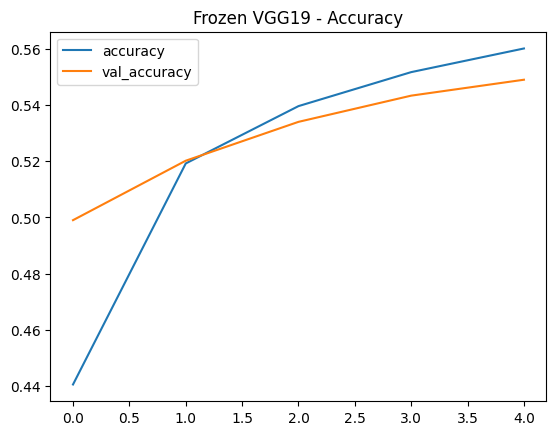

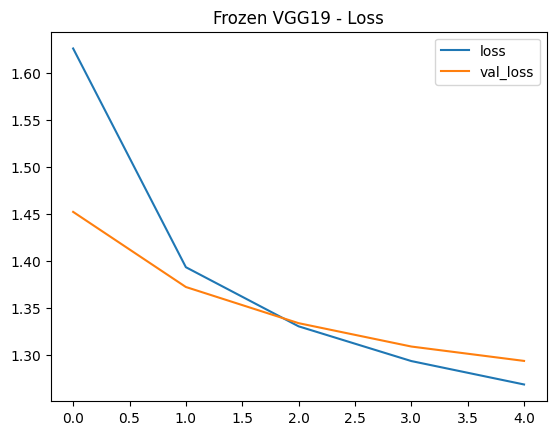

In [9]:
df_frozen = pd.DataFrame(history_frozen.history).drop(columns=['learning_rate'])

df_frozen[["accuracy", "val_accuracy"]].plot(title="Frozen VGG19 - Accuracy")
df_frozen[["loss", "val_loss"]].plot(title="Frozen VGG19 - Loss");

## 5 - Fine-tuning (unfreeze last 5 layers)

We now unfreeze the last convolutional layers of VGG19 and fine‑tune them with a lower learning rate.

In [10]:
# Unfreeze last 5 layers
for layer in base_model.layers[-5:]:
    layer.trainable = True

# Compile with new state
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), #Reduce LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history_ft= model.fit(
    batch_train,
    epochs=10,
    validation_data=batch_val,
    callbacks=get_callbacks('vgg_ft'),
    verbose=2
    )

Epoch 1/10
750/750 - 14s - 19ms/step - accuracy: 0.6367 - loss: 1.0486 - val_accuracy: 0.6625 - val_loss: 0.9685 - learning_rate: 1.0000e-05
Epoch 2/10
750/750 - 7s - 9ms/step - accuracy: 0.7082 - loss: 0.8359 - val_accuracy: 0.6780 - val_loss: 0.9090 - learning_rate: 1.0000e-05
Epoch 3/10
750/750 - 8s - 10ms/step - accuracy: 0.7485 - loss: 0.7238 - val_accuracy: 0.6942 - val_loss: 0.8676 - learning_rate: 1.0000e-05
Epoch 4/10
750/750 - 8s - 10ms/step - accuracy: 0.7785 - loss: 0.6385 - val_accuracy: 0.7035 - val_loss: 0.8502 - learning_rate: 1.0000e-05
Epoch 5/10
750/750 - 7s - 9ms/step - accuracy: 0.8036 - loss: 0.5693 - val_accuracy: 0.7168 - val_loss: 0.8188 - learning_rate: 1.0000e-05
Epoch 6/10
750/750 - 8s - 10ms/step - accuracy: 0.8283 - loss: 0.5045 - val_accuracy: 0.7252 - val_loss: 0.8043 - learning_rate: 1.0000e-05
Epoch 7/10
750/750 - 7s - 9ms/step - accuracy: 0.8491 - loss: 0.4503 - val_accuracy: 0.7228 - val_loss: 0.8184 - learning_rate: 1.0000e-05
Epoch 8/10
750/750 - 8

In [11]:
# Load best weights
model.load_weights('checkpoints/vgg_ft.weights.h5')

# Evaluate on test data :
test_accuracy_ft = model.evaluate(batch_test)[1]
print("Accuracy fine-tuned VGG19 (5 layers) :", test_accuracy_ft)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7610 - loss: 0.7521
Accuracy fine-tuned VGG19 (5 layers) : 0.7513333559036255


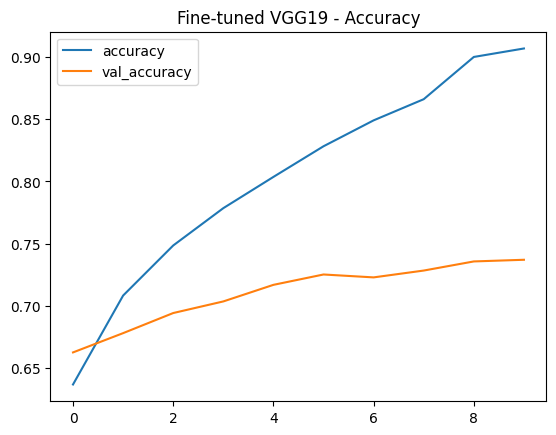

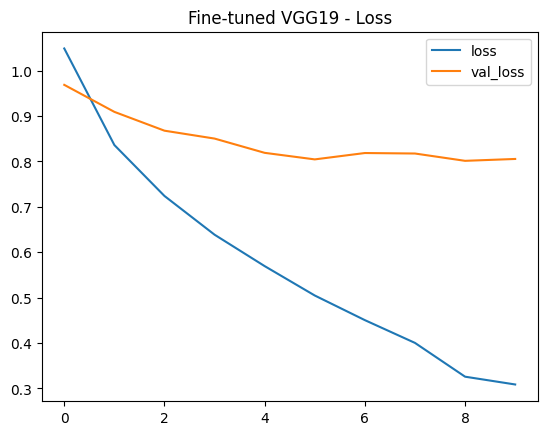

In [12]:
df_ft = pd.DataFrame(history_ft.history).drop(columns=['learning_rate'])

df_ft[["accuracy", "val_accuracy"]].plot(title="Fine-tuned VGG19 - Accuracy")
df_ft[["loss", "val_loss"]].plot(title="Fine-tuned VGG19 - Loss");

## 6 - Fine-tuning + Dropout (0.2)

To mitigate overfitting, we add a Dropout layer after the global pooling layer and repeat the fine‑tuning procedure.

In [13]:
# Create model WITH Dropout
model_drop, base_model_drop = create_vgg(add_dropout=True)

# Head Training
history_head_drop = model_drop.fit(
    batch_train,
    validation_data=batch_val,
    epochs=5,
    callbacks=get_callbacks('vgg_drop_head'),
    verbose=2
)

# Load best weights
model_drop.load_weights("checkpoints/vgg_drop_head.weights.h5")

# Unfreeze and recompile
for layer in base_model_drop.layers[-5:]:
  layer.trainable = True

model_drop.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tuning
history_drop = model_drop.fit(
    batch_train,
    validation_data=batch_val,
    epochs=10,
    callbacks=get_callbacks('vgg_drop'),
    verbose=2
)

Epoch 1/5
750/750 - 11s - 15ms/step - accuracy: 0.4087 - loss: 1.6919 - val_accuracy: 0.4992 - val_loss: 1.4773 - learning_rate: 1.0000e-03
Epoch 2/5
750/750 - 6s - 8ms/step - accuracy: 0.4876 - loss: 1.4707 - val_accuracy: 0.5117 - val_loss: 1.4027 - learning_rate: 1.0000e-03
Epoch 3/5
750/750 - 10s - 14ms/step - accuracy: 0.5035 - loss: 1.4239 - val_accuracy: 0.5243 - val_loss: 1.3665 - learning_rate: 1.0000e-03
Epoch 4/5
750/750 - 7s - 9ms/step - accuracy: 0.5103 - loss: 1.3993 - val_accuracy: 0.5300 - val_loss: 1.3482 - learning_rate: 1.0000e-03
Epoch 5/5
750/750 - 6s - 8ms/step - accuracy: 0.5158 - loss: 1.3850 - val_accuracy: 0.5335 - val_loss: 1.3367 - learning_rate: 1.0000e-03
Epoch 1/10
750/750 - 14s - 19ms/step - accuracy: 0.6029 - loss: 1.1285 - val_accuracy: 0.6488 - val_loss: 0.9891 - learning_rate: 1.0000e-05
Epoch 2/10
750/750 - 8s - 10ms/step - accuracy: 0.6792 - loss: 0.9076 - val_accuracy: 0.6768 - val_loss: 0.9130 - learning_rate: 1.0000e-05
Epoch 3/10
750/750 - 8s -

In [18]:
# Load best weights
model_drop.load_weights("checkpoints/vgg_drop.weights.h5")

# Evaluate on test data :
test_accuracy_drop = model_drop.evaluate(batch_test)[1]
print("Accuracy fine-tuned VGG19 with dropout :", test_acc_drop)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7577 - loss: 0.7270
Accuracy fine-tuned VGG19 with dropout : 0.7508333325386047


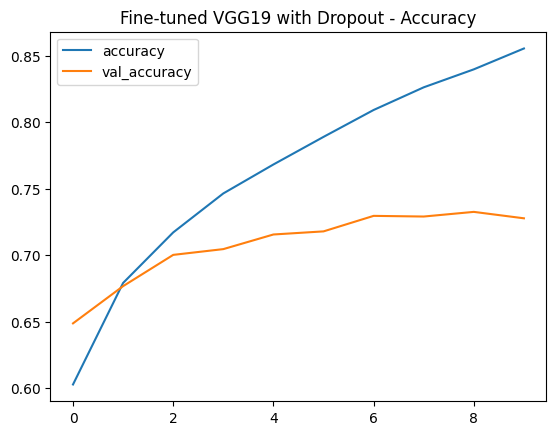

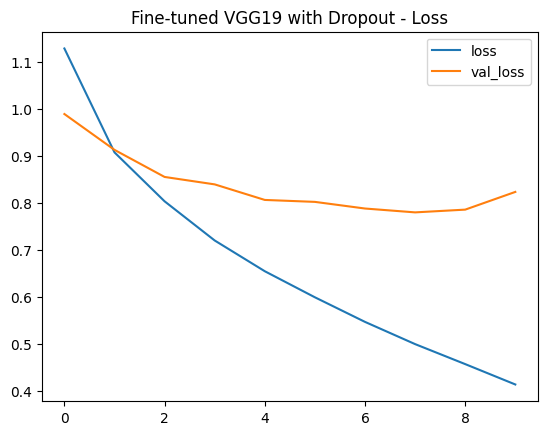

In [15]:
df_drop = pd.DataFrame(history_drop.history).drop(columns=['learning_rate'])

df_drop[["accuracy", "val_accuracy"]].plot(title="Fine-tuned VGG19 with Dropout - Accuracy")
df_drop[["loss", "val_loss"]].plot(title="Fine-tuned VGG19 with Dropout - Loss");

## 7 - Final Results

In [19]:
results_vgg = pd.DataFrame({
    "Model": [
        "VGG19 frozen",
        "VGG19 fine-tuned (5 layers)",
        "VGG19 fine-tuned + Dropout"
    ],
    "Test accuracy": [
        test_accuracy_frozen,
        test_accuracy_ft,
        test_accuracy_drop
    ]
})

results_vgg

,Model,Test accuracy
0,VGG19 frozen,0.561667
1,VGG19 fine-tuned (5 layers),0.751333
2,VGG19 fine-tuned + Dropout,0.750833


## 8 - Confusion matrix

We now analyze the final VGG19 model using a confusion matrix to understand which classes remain challenging.

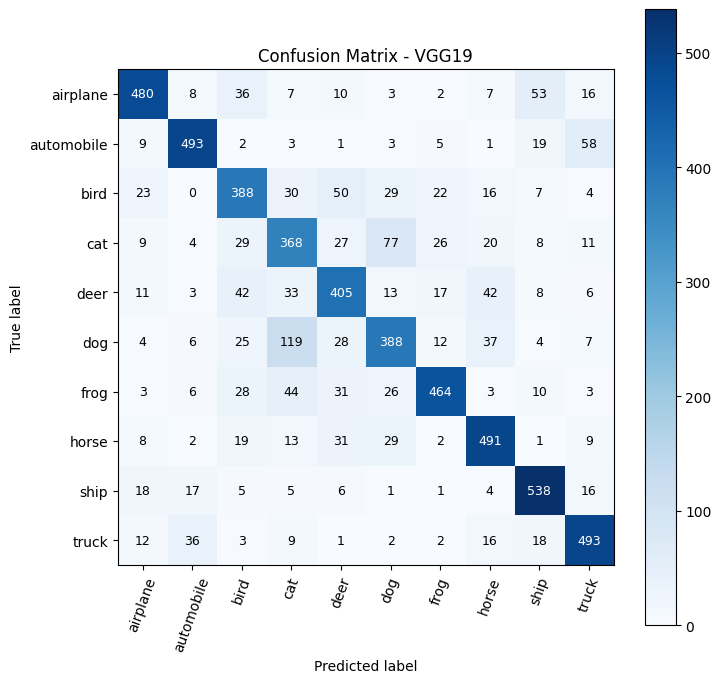

In [29]:
model_drop.load_weights("checkpoints/vgg_ft.weights.h5")
class_names = infos.features['label'].names

# Confusion matrix

y_true = []
y_pred = []

for images, labels in batch_test:
    preds = model_drop.predict(images, verbose=0)
    y_true.append(labels)
    y_pred.append(np.argmax(preds, axis=1))

y_true = tf.concat(y_true, axis=0)
y_pred = tf.concat([tf.convert_to_tensor(p) for p in y_pred], axis=0)

cm = confusion_matrix(y_true, y_pred)
n_classes = len(class_names)

fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

ax.set(
    title="Confusion Matrix - VGG19",
    xlabel="Predicted label",
    ylabel="True label",
    xticks=np.arange(n_classes),
    yticks=np.arange(n_classes),
    xticklabels=class_names,
    yticklabels=class_names
)

ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()
plt.xticks(rotation=70, fontsize=10)
plt.yticks(fontsize=10)

threshold = (cm.max() + cm.min()) / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j, i, f"{cm[i, j]}",
        ha="center",
        va="center",
        color="white" if cm[i, j] > threshold else "black",
        fontsize=9
    )

plt.show()

## 9 - Misclassified Examples :

We inspect a few misclassified samples to better understand typical failure modes of the VGG19 model.

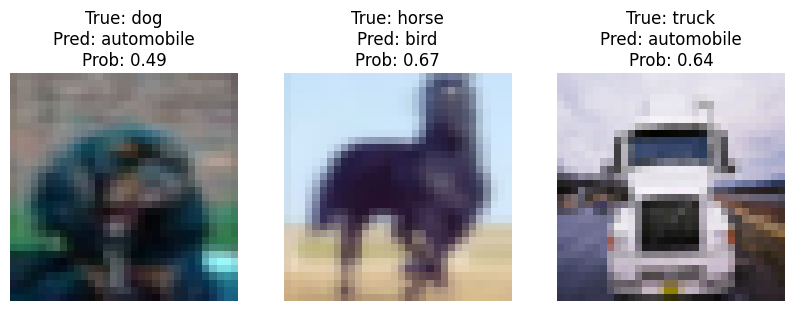

In [30]:
wrong_images = []
wrong_true = []
wrong_pred = []
wrong_prob = []

for images, labels in batch_test:
    preds = model_drop.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    probs = np.max(preds, axis=1)

    for img, true_l, pred_l, p in zip(images, labels.numpy(), pred_labels, probs):
        if true_l != pred_l:
            wrong_images.append(tf.cast(img, tf.float32).numpy()) # Cast to float32
            wrong_true.append(true_l)
            wrong_pred.append(pred_l)
            wrong_prob.append(np.round(float(p), 2))
        if len(wrong_images) == 3:
            break
    if len(wrong_images) == 3:
        break

plt.figure(figsize=(10, 4))
for i in range(len(wrong_images)):
    plt.subplot(1, len(wrong_images), i + 1)
    plt.imshow(wrong_images[i])
    true_label = class_names[wrong_true[i]]
    pred_label = class_names[wrong_pred[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}\nProb: {wrong_prob[i]}")
    plt.axis("off")
plt.show()

## 10 - Conclusion :

We explored transfer learning on CIFAR‑10 using VGG19 pretrained on ImageNet.  
Starting from a frozen backbone, we trained a classifier head, then fine‑tuned the last convolutional layers, and finally added Dropout to mitigate overfitting.

Fine‑tuning improved performance over the frozen baseline, while Dropout helped stabilize validation loss and slightly improved generalization.  
However, VGG19 remains a large and relatively heavy model compared to the custom CNN developed in the previous notebooks.

In practice, our custom CNN offers a better trade‑off between performance, efficiency, and simplicity,  
while VGG19 serves as a useful benchmark and confirms that our architecture is competitive with a pretrained backbone on CIFAR‑10.